# Lab 4

This lab covers the lectures from the fourth week of class - 9, 10, 11:
- Transformations/PCA
- Support Vector Machines (SVM)
- Statistical Evaluation

### Learning Objectives
- Understand the basic linear algebra behing PCA
- Apply PCA to the PBMC dataset to see how it can be helpful in speeding up k-NN
- Visually and mathematically explore the kernel trick using polynomial and RBF kernels
- Use cross-validation and statistical evaluations to compare SVM kernels on a real-world dataset
- Evaluate and quantitatively compare models on a classification task of your choice

### Submission And Assignment Instructions
Submit your `Lab4_lastname_firstname.pdf` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you. Follow the posted instructions to download your lab as a well-formatted .pdf.

Formatting Notes:
- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `##❓YOUR CODE HERE`

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

## Section 1: PCA Transformations

### 1.1: Load the data

Run the code block below to load the dataset and get started.

In [21]:
# load packages and the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# load local file "data_03_pbmcs.txt"
# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
  # print('User uploaded file "{name}" with length {length} bytes'.format(
      # name=fn, length=len(uploaded[fn])))

# load the pbmc data as a pandas df
pbmc = pd.read_csv("data_03_pbmc.txt",
                   header=0,
                   sep = "\t",
                   quotechar = '"',
                   quoting = 0)
print(pbmc.shape)

# transpose to flip cells (observations) into rows
pbmc = pbmc.transpose()
print(pbmc.shape)

# Load the celltype labels as a pd df
# uploaded = files.upload()

# for fn in uploaded.keys():
  # print('User uploaded file "{name}" with length {length} bytes'.format(
      # name=fn, length=len(uploaded[fn])))

pbmc_idents = pd.read_csv("data_04_pbmcidents.txt",
                          header=0,
                          sep = "\t",
                          quotechar = '"',
                          quoting = 0)

(2000, 2638)
(2638, 2000)


### 1.2: Centering and Scaling the Data & Initial PCA Visualizations

❓1.2.1 Why is it important to mean-center data (adjust the mean to 0) before doing PCA?

✅ Answer: PCA finds directions of maximum variance, and the covariance matrix measures spread around the mean. Without centering, the first PC points toward the data's mean (offset from origin) instead of the direction of greatest spread, so the components describe location rather than variation.

❓1.2.2 Why is it important to scale the data to have a standard deviation of 1 across features before doing PCA?

✅ Answer: Again, PCA is driven by variance, so features measured on larger scales dominate the components regardless of how informative they are. Scaling to unit variance puts all features (genes in this case) on equal footing, so PCs reflect correlation structure rather than units or magnitude.

❓1.2.3 How many principals components could be produced for a dataset with dimension 12. How then, can we use PCA as a dimensionality reduction tool?

✅ Answer: Up to 12 PCs; PCA reduces dimensionality because the PCs are ordered by variance explained. We keep the first k that capture most of the variance and drop the rest because they are mostly noise.

❓1.2.4 Write code below to standardize and scale the data, then apply PCA to find the first 50 principal components. Visualize the whole PBMC dataset in the plane of the first two principal components, coloring by the cell identities.
- Make sure to label the axes, including the proportion of variance explained by that principal component. (Have a look at `pca.explained_variance_ratio_`)
- Adjust `alpha` to avoid overplotting

Explained variance ratio of the first 50 principal components: [0.02540579 0.01441399 0.01025347 0.00736164 0.00520757 0.00369867
 0.00350014 0.00312259 0.00273572 0.00263756 0.0023015  0.00214549
 0.00205085 0.00189093 0.00181568 0.00179107 0.00173576 0.00171369
 0.00167585 0.00166668 0.00163056 0.00161796 0.00160945 0.00159716
 0.00159277 0.00157749 0.00157455 0.00156486 0.00155709 0.00154286
 0.00153622 0.00153331 0.00152922 0.00152184 0.00151109 0.00150419
 0.00149353 0.00149086 0.00148368 0.00147981 0.00146824 0.00145547
 0.00144637 0.00144368 0.00143843 0.0014362  0.0014176  0.00141342
 0.00141155 0.00140705]


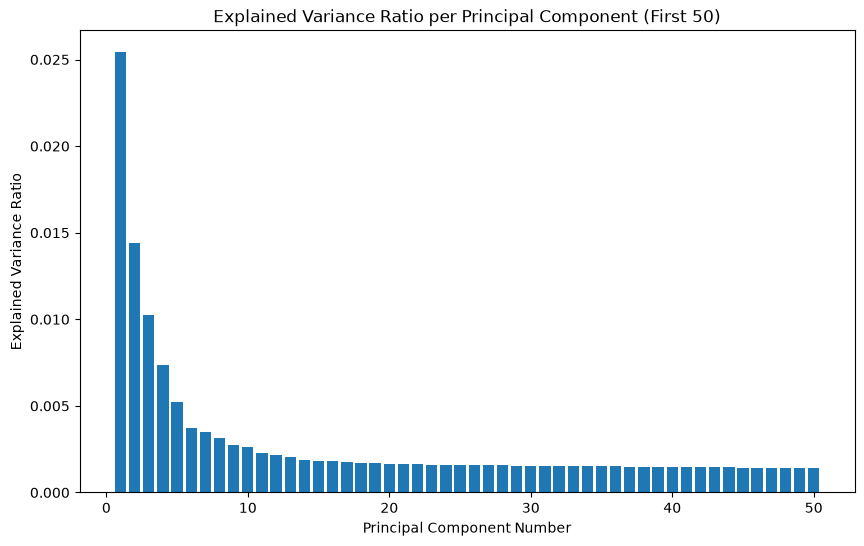

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

##❓YOUR CODE HERE
# scale the data
scaler = StandardScaler()
X = scaler.fit_transform(pbmc)

# apply PCA
pca = PCA(n_components=50)
pbmcPCA = pca.fit_transform(X)

# Get and print the explained variance ratio
expVar = pca.explained_variance_ratio_
pca1 = expVar[0]*100
pca2 = expVar[1]*100
print("Explained variance ratio of the first 50 principal components:", expVar)

# Plot the explained variance over the principal components (make sure to include labels on the plot)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(expVar) + 1), expVar)
plt.xlabel("Principal Component Number")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio per Principal Component (First 50)")
plt.show()

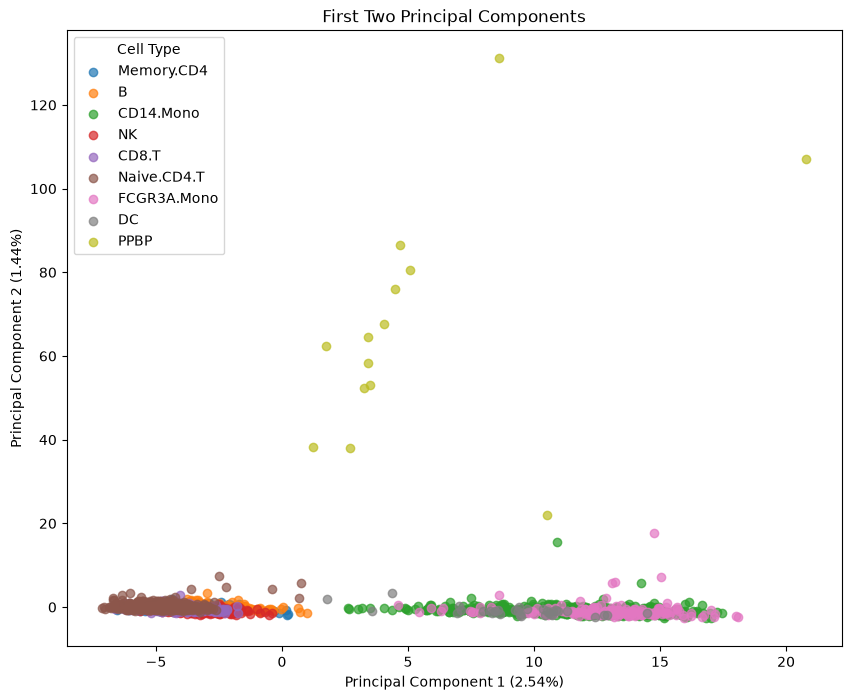

In [23]:
# Visualize the first two principal components
plt.figure(figsize= (10, 8))
cellTypes = pbmc_idents.iloc[:, 0] #Label pbmc rows
for c in cellTypes.unique():
    mask = (cellTypes==c)
    plt.scatter(pbmcPCA[mask, 0],
                pbmcPCA[mask, 1],
                label=c,
                alpha=0.7)
plt.xlabel(f"Principal Component 1 ({expVar[0]*100:.2f}%)")
plt.ylabel(f"Principal Component 2 ({expVar[1]*100:.2f}%)")
plt.title("First Two Principal Components")
plt.legend(title="Cell Type", loc="best")
plt.show()

❓1.2.5 Modify the code below as necessary to make a pairwise plot (use `sns.pairplot`) of the first 4 principal components. *This should take minimal modification, just substituting some of your variable names.*
- continue to label the percentage of variation explained in your axis labels

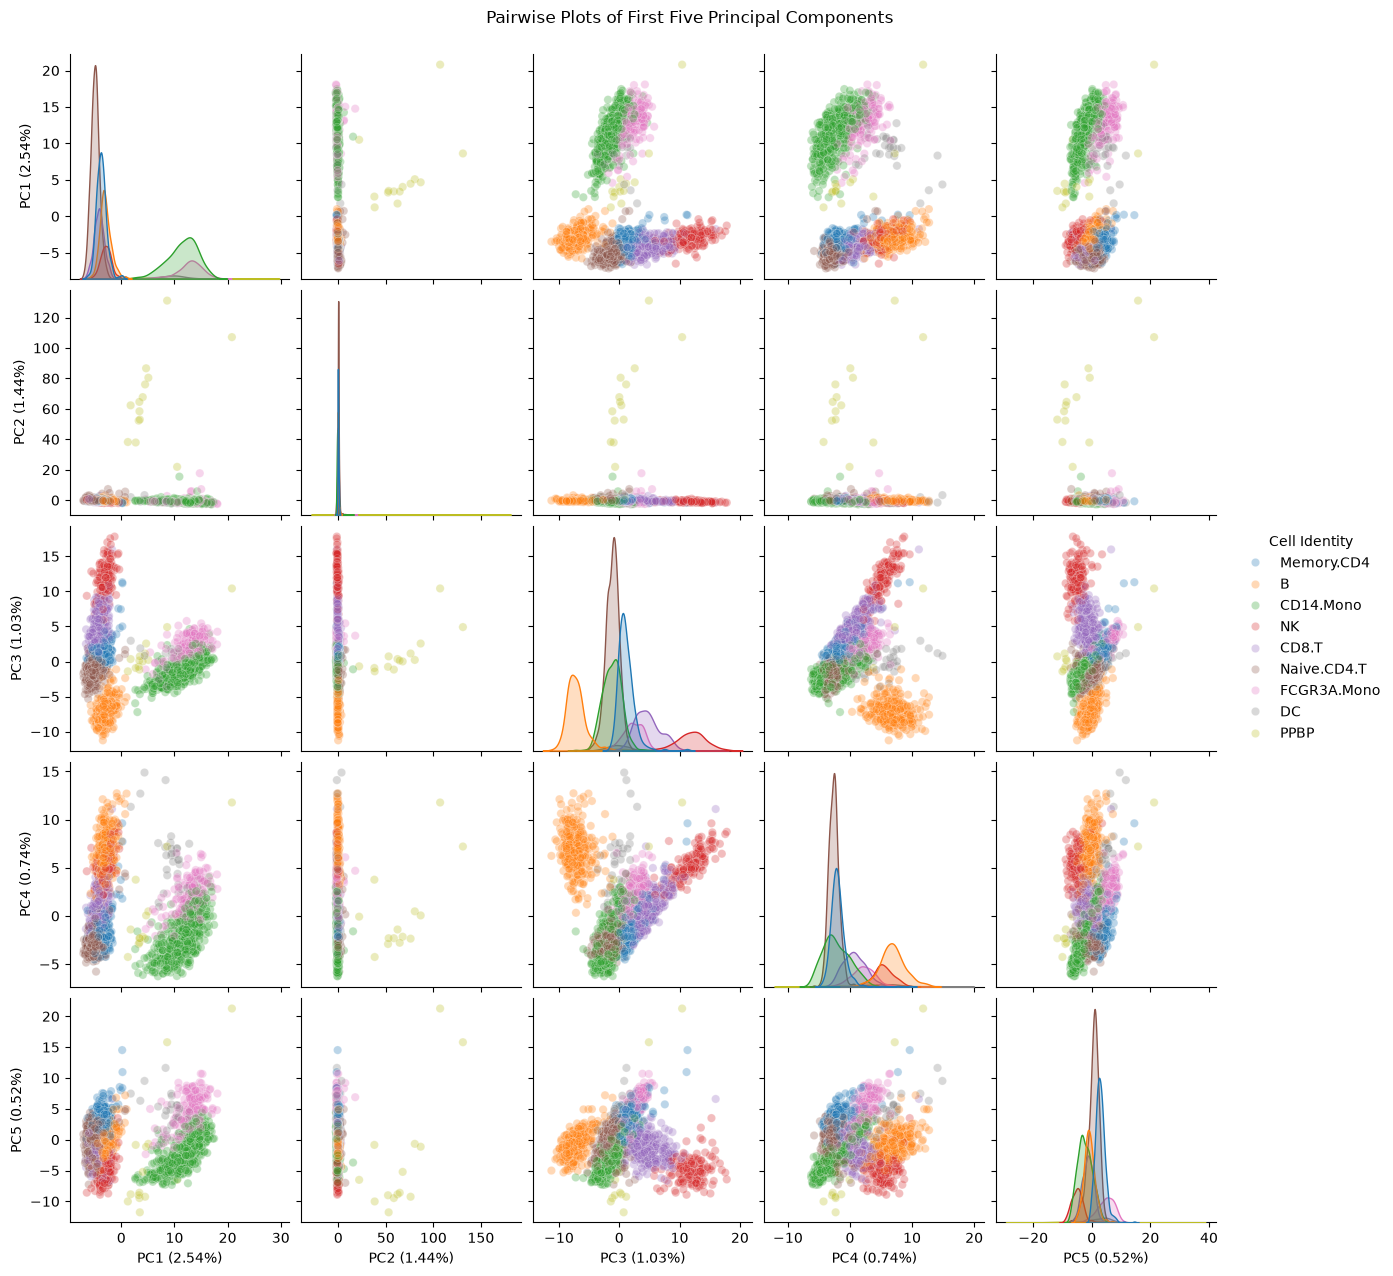

In [24]:
##❓YOUR CODE HERE
# modify as necessary to match your variable names from above to generate the pairplot

# Create a DataFrame with the first five principal components and the labels
pcaDf = pd.DataFrame(data=pbmcPCA[:, :5],
                      columns=[f'PC{i+1}' for i in range(5)])
pcaDf['Label'] = pbmc_idents.iloc[:, 0].values

# Create the pairplot with seaborn and adjust alpha for plotting
g = sns.pairplot(pcaDf, hue='Label',
                 plot_kws={'alpha': 0.3})

# Generate axis labels using the percentage of variation explained
# modify to get the correct explained_variance
axis_labels = [f'PC{i+1} ({expVar[i]*100:.2f}%)' for i in range(5)]

# Add labels to the axes using a for loop
for i, label in enumerate(axis_labels):
    for j in range(5):
        if i == 4:
            g.axes[i, j].set_xlabel(axis_labels[j])
        if j == 0:
            g.axes[i, j].set_ylabel(axis_labels[i])
# title the plot and legend
g._legend.set_title('Cell Identity')
plt.suptitle('Pairwise Plots of First Five Principal Components', y =1.02)
plt.show()

### 1.3: Explained Variance

❓1.3.1 Plot the explained variance from the first 1000 principal components. This is often called an "Elbow Plot" to help data scientists look for the turn or "elbow" on the plot where the explained variance drops off.  *Hint: You'll need to redo the PCA with more principal components.*

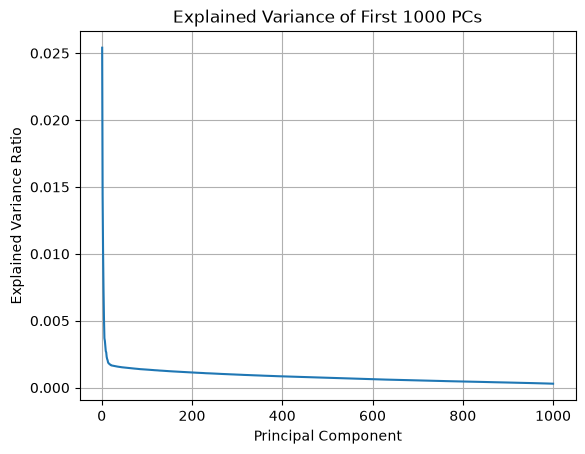

In [25]:
##❓YOUR CODE HERE

# apply PCA
pca1000 = PCA(n_components=1000)
pbmcPCA1000 = pca1000.fit_transform(X)

# Get the explained variance ratio
expVar1000 = pca1000.explained_variance_ratio_

# Create the elbow plot (make sure to include labels on the plot)
plt.figure()
plt.plot(np.arange(1, len(expVar1000)+1), expVar1000)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance of First 1000 PCs")
plt.grid(True)
plt.show()

❓1.3.2 Briefly interpret what you see on your elbow plot. How many principal components are important to keep in this dataset? Does adding more principal components continue to add more variation to the dataset?

✅ Answer: Explained variance drops steeply over the first 5 to 7 PCs and flattens after about PC 10, where each PC adds only about 0.2%. Keeping about 10 PCs is reasonable. Additional PCs always add some variance, but past the elbow the changes are small, near-uniform, and mostly noise, so they barely contribute meaningfully.

❓1.3.3 Another way to visualize explained variance is using cumulative explained variance. In the code block below, plot the cumulative explained variance to see how much variance the first 1000 principal components explain in total.

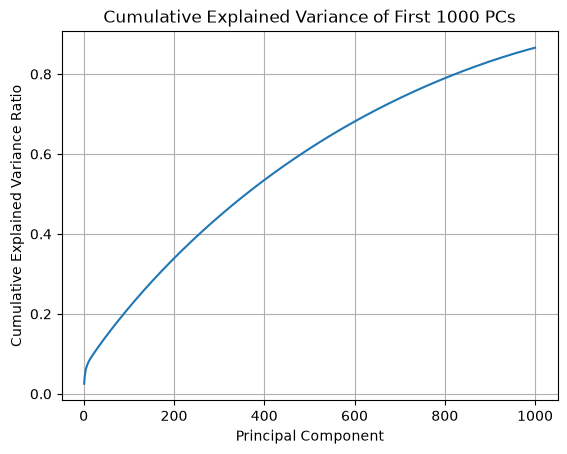

In [26]:
# Get the explained variance ratio
#explained_variance = # fill this in

# Cumulative explained variance (use np.cumsum)
cumExpVar = np.cumsum(expVar1000)

# Create the elbow plot (make sure to include labels)
plt.figure()
plt.plot(np.arange(1, len(cumExpVar)+1), cumExpVar)
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance of First 1000 PCs")
plt.grid(True)
plt.show()

## Section 2: PCA by Hand for 2 Datapoints

In this section we are going to do the math behind PCA for a 2x2 matrix. We will walk through every step, but the goal is to find the principal components for 2 datapoints: ($x_1$=1, $y_1$=2) and ($x_2$=3, $y_2$=4).

❓ 2.1 Create a matrix $X$ given the two datapoints. *Hint: Each datapoint should be a row of the matrix.*

> ✅Answer:![Problem21](Problem21.jpeg)

❓ 2.2 Next, we need to center the data in the matrix. We are going to do this for our x coordinates and y coordinate separately. First, find the mean of the x coordinates (first column), and subtract it from the x coordinates. Repeat this for the y coordinates (second column).

> ✅Answer:![Problem22](Problem22.jpeg)

❓ 2.3 Now we need to find the covariance matrix. The formula for covariance is usually $\text{Cov}(x,y) = \frac{\sum (x-\bar{x})(y-\bar{y})}{n-1}$ assuming a Bessel correction is used. However, since we already simplified the data, the formula for covariance is simply $\frac{X^TX}{n-1}$.

> ✅Answer:![Problem23](Problem23.jpeg)

❓ 2.4.1 The next step is to find the eigenvalues of the covariance matrix. *Hint: We find eigenvalues by solving $det(A-λI) = 0$ where $I$ is the identity matrix.*

> ✅Answer:![Problem241](Problem241.jpeg)

❓ 2.4.2 Explain what the eigenvalues represent for the matrix $X$. Consider what they could be for the principal components or PCA in general.

✅Answer: Each eigenvalue is the variance of the data along its eigenvector, that is, along that principal component. λᵢ / Σλ is the proportion of variance that PC explains.

❓ 2.5 From the eigenvalues, find the eigenvectors. Be sure to normalize the eigenvectors after finding them. *Hint: Solve $Av = \lambda v$.*

> ✅Answer:![Problem25](Problem25.jpeg)

❓ 2.6 Finally, transform the data by the centered matrix by the principal component matrix. *Hint: transformed matrix = centered matrix * eigenvector matrix (where each eigenvector is a column).*

> ✅Answer:![Problem26](Problem26.jpeg)

❓ 2.7 Explain your results briefly. Specifically, how many principal components are there, how much variance is explained by each one, and how many datapoints could we represent this data with?

✅ Answer: There are 2 PCs. PC1 explains 100% of the variance and PC2 explains 0% because the two points lie on a single line. The data can be represented with one dimension, a single coordinate per point, and no information lost.

## Section 3: Exploring Kernels

We're going to work a small example explicitly to show the advantage of the kernel trick.

### 3.1: Polynomial Kernel Math

We have data points $\vec x = \langle x_1,x_2 \rangle$ and $\vec y = \langle y_1,y_2 \rangle$ that we'll represent as vectors in our 2-D input space.

❓3.1.1 Compute the projections $\vec x → \phi(\vec x)$ and $\vec y → \phi(\vec y)$ explicitly for $\phi(\vec x ) = \langle x_1^2, x_2^2, \sqrt{2} x_1, \sqrt{2} x_2, \sqrt{2} x_1x_2,1 \rangle$. Then compute the new inner product $K(\vec x, \vec y) = \phi(\vec x) \cdot \phi(\vec y)$ explicitly. *Your answer should be a polynomial in terms of $x_1, x_2, y_1,$ and $y_2$.*

> ✅Answer:![Problem311](Problem311.jpeg)

❓3.1.2 Show that this dot product in high dimensional feature space is the same as $K(\vec x, \vec y) = (\vec x \cdot \vec y + 1)^2$ by expanding the right-hand side. This is what is usually called the polynomial kernel function with degree 2!

> ✅Answer:![Problem312](Problem312.jpeg)

You can see that our 2-D input space ($\vec x \in \mathbb{R}^2$) mapped to a 6-D feature space ($\phi(\vec x) \in \mathbb{R}^6$). [It can be shown](https://en.wikipedia.org/wiki/Polynomial_kernel#Definition) that a polynomial kernel maps to ${n+d}\choose{d}$ dimensions.

❓ 3.1.3 If we start with $n$ attributes in the input feature space, using a 2nd degree polynomial kernel, what is the dimensionality of the higher dimensional feature space?

> ✅Answer:![Problem313](Problem313.jpeg)

Final answer = (n+2)(n+1)/2

### 3.2: Visualizing Polynomial Kernels

Let's visualize the transformation we just explicitly computed.

❓3.2.1 The first part of the code below is outlined for you. Calculate and plot the kernel function for the given X and Y values (in a meshgrid).

> [This video](https://www.youtube.com/watch?v=OdlNM96sHio) also shows a visualization of the polynomial kernel.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import polynomial_kernel

# Define the range of x and y values
x = np.linspace(-5, 5, 101)
y = np.linspace(-5, 5, 101)

# Create a meshgrid of x and y values
X, Y = np.meshgrid(x, y)

Text(0.5, 1.0, 'Polynomial Kernel Matrix Heatmap')

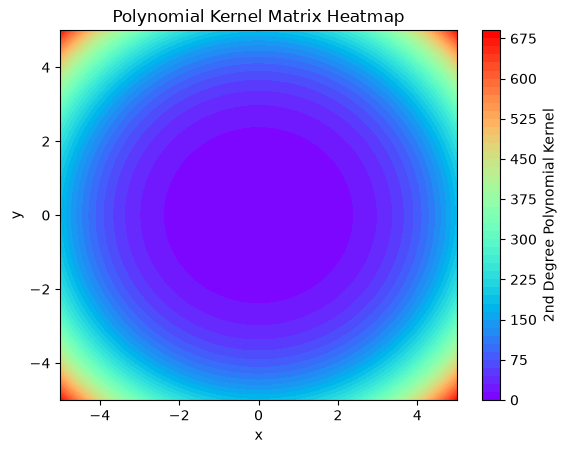

In [28]:
##❓YOUR CODE HERE
# Compute the polynomial kernel matrix for a 2nd degree
points = np.c_[X.ravel(), Y.ravel()]
K = polynomial_kernel(points, points, degree=2)

# Create a heatmap of the kernel matrix (include labels)
K_plot = np.diag(K).reshape(X.shape)
plt.figure()
plt.contourf(X, Y, K_plot, levels=50, cmap="rainbow")
plt.colorbar(label="2nd Degree Polynomial Kernel")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Kernel Matrix Heatmap")

## Section 4: Support Vector Machines

We're going to try using SVM to improve our classification on a non-linear classification task.

❓4.1 Write code to run SVM on the PBMC data with a linear kernel, polynomial kernel, and RBF kernel, using 10-fold cross-validation on each. Visualize the accuracy and recall for each kernel, plotting error bars as SEM.

Kernel: Linear, Accuracy: 0.9136 ± 0.0052, Recall: 0.9218 ± 0.0093
Kernel: Polynomial, Accuracy: 0.2775 ± 0.0013, Recall: 0.2031 ± 0.0146
Kernel: RBF, Accuracy: 0.9003 ± 0.0050, Recall: 0.7071 ± 0.0046


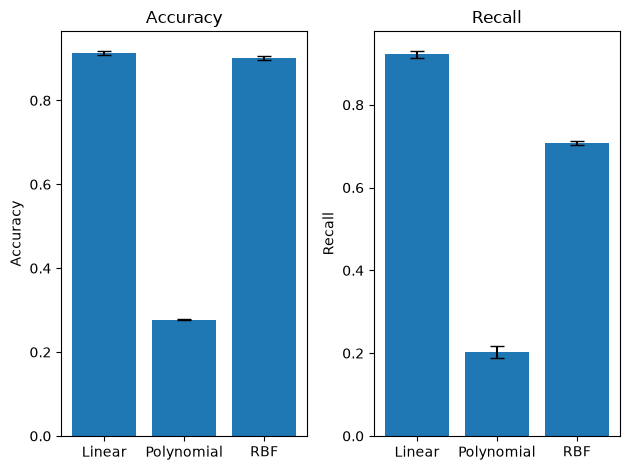

In [29]:
##❓YOUR CODE HERE
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from scipy.stats import sem

# Assuming 'pbmc' is your features DataFrame and 'pbmc_idents' contains the labels
X = pbmc
y = pbmc_idents.iloc[:, 0]  # Adjust the column index if necessary

# Standardize the features
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=10)
stats = []

# Define the kernels to compare
kernels = ['linear', 'poly', 'rbf']
kernel_names = {'linear': 'Linear',
                'poly': 'Polynomial',
                'rbf': 'RBF'}

# Perform 10-fold cross-validation for each kernel and collect metrics
# Calculate mean and standard error of the mean (SEM)
for kernel in kernels:
    model = make_pipeline(StandardScaler(),
                          SVC(kernel=kernel,
                              random_state=10))
    cvResults = cross_validate(model,
                               X,
                               y,
                               cv=10,
                               scoring=["accuracy", "recall_macro"])
    accMean, accSEM = cvResults["test_accuracy"].mean(), sem(cvResults["test_accuracy"])
    recMean, recSEM = cvResults["test_recall_macro"].mean(), sem(cvResults['test_recall_macro'])
    stats.append({"Kernel": kernel_names[kernel],
                  "Accuracy": accMean, "Accuracy_SEM": accSEM,
                  "Recall": recMean, "Recall_SEM": recSEM})
    print(f"Kernel: {kernel_names[kernel]}, Accuracy: {accMean:.4f} ± {accSEM:.4f}, "
          f"Recall: {recMean:.4f} ± {recSEM:.4f}")

# Plot the results
statsDf = pd.DataFrame(stats)
fig, ax = plt.subplots(1, 2)
ax[0].bar(statsDf["Kernel"],
          statsDf["Accuracy"],
          yerr=statsDf["Accuracy_SEM"],
          capsize=5)
ax[0].set_title("Accuracy")
ax[0].set_ylabel("Accuracy")
ax[1].bar(statsDf["Kernel"],
          statsDf["Recall"],
          yerr=statsDf["Recall_SEM"],
          capsize=5)
ax[1].set_title("Recall")
ax[1].set_ylabel("Recall")
plt.tight_layout()
plt.show()

❓4.2 Briefly interpret your results comparing these kernels. (one sentence).

✅Answer: Linear (91% accuracy, 92% recall) and RBF (90% accuracy) have similar accuracy, but RBF's recall drops to 71%, meaning it misses rare cell types; therefore, linear performs best (consistent with the classes being largely linearly separable).

❓4.3 Explain what precision and recall are and why accuracy should not be the only metric reported.

✅Answer: Precision = TP/(TP+FP) -- of the cells predicted as a class, it's the fraction that truly belong to it. Recall = TP/(TP+FN) -- of the cells that truly belong to a class, it's the fraction the model found. A model can score high accuracy by getting the common classes right while failing on rare ones. The RBF kernel here exemplifies this.